<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第 5 章：在未标记数据上进行预训练

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.7
numpy version: 2.3.4
tiktoken version: 0.12.0
torch version: 2.9.0
tensorflow version: 2.20.0


- In this chapter, we implement the training loop and code for basic model evaluation to pretrain an LLM
- At the end of this chapter, we also load openly available pretrained weights from OpenAI into our model

- 在本章中，我们实现训练循环和用于基本模型评估的代码，以预训练一个 LLM
- 在本章末尾，我们还将把 OpenAI 公开可用的预训练权重加载到我们的模型中

- The topics covered in this chapter are shown below

- 本章涵盖的主题如下所示

&nbsp;
## 5.1 Evaluating generative text models

&nbsp;
## 5.1 评估生成文本模型

- 我们首先简要回顾一下使用上一章的代码初始化 GPT 模型
- 然后，我们讨论 LLM 的基本评估指标
- 最后，在本节中，我们将这些评估指标应用于训练和验证数据集

&nbsp;
### 5.1.1 使用 GPT 生成文本

In [2]:
- 我们使用上一章的代码初始化一个 GPT 模型

- We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays
- Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting `"qkv_bias": False`
- We reduce the context length (`context_length`) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens
  - This is so that more readers will be able to follow and execute the code examples on their laptop computer
  - However, please feel free to increase the `context_length` to 1024 tokens (this would not require any code changes)
  - We will also load a model with a 1024 `context_length` later from pretrained weights

- 我们在上面使用了 0.1 的 Dropout，但现在训练不带 Dropout 的 LLM 相对普遍
- 现代 LLM 也不在查询、键和值矩阵的 `nn.Linear` 层中使用偏置向量（这与早期的 GPT 模型不同），这是通过设置 `"qkv_bias": False` 来实现的
- 我们将上下文长度（`context_length`）减少到仅 256 个标记，以减少训练模型所需的计算资源，而最初的 1.24 亿参数 GPT-2 模型使用了 1024 个标记
  - 这样更多的读者就可以在他们的笔记本电脑上跟随并执行代码示例
  - 但是，请随意将 `context_length` 增加到 1024 个标记（这不需要任何代码更改）
  - 我们稍后也将从预训练权重加载具有 1024 `context_length` 的模型

- 接下来，我们使用上一章的 `generate_text_simple` 函数来生成文本
- 此外，我们定义了两个便利函数 `text_to_token_ids` 和 `token_ids_to_text`，用于在本章中使用的标记和文本表示之间进行转换

In [3]:
import tiktoken
from previous_chapters import generate_text_simple

# Alternatively:
# from llms_from_scratch.ch04 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- 正如我们在上面看到的，模型没有生成好的文本，因为它还没有经过训练
- 我们如何以数字形式衡量或捕捉什么是“好文本”，以便在训练期间对其进行跟踪？
- 下一小节介绍了计算生成输出的损失指标的方法，我们可以用它来衡量训练进度
- 关于微调 LLM 的后续章节也将介绍衡量模型质量的其他方法

&nbsp;
### 5.1.2 计算文本生成损失：交叉熵和困惑度

- 假设我们有一个 `inputs` 张量，其中包含 2 个训练示例（行）的标记 ID
- 与 `inputs` 相对应，`targets` 包含我们希望模型生成的期望标记 ID
- 请注意，`targets` 是 `inputs` 移动了 1 个位置，正如我们在第 2 章实现数据加载器时所解释的那样

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- 将 `inputs` 输入模型，我们获得 2 个输入示例的 logits 向量，每个示例包含 3 个标记
- 每个标记都是一个对应于词汇表大小的 50,257 维向量
- 应用 softmax 函数，我们可以将 logits 张量转换为包含概率分数的相同维度的张量

In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- 下图使用非常小的词汇表进行说明，概述了我们将概率分数转换回文本的方式，我们在上一章末尾讨论过这一点

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/02.webp" width=500px>

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/04.webp" width=500px>

- 正如在上一章中讨论的那样，我们可以应用 `argmax` 函数将概率分数转换为预测的标记 ID
- 上面的 softmax 函数为每个标记生成了一个 50,257 维的向量；`argmax` 函数返回此向量中最高概率分数的位置，即给定标记的预测标记 ID

- 由于我们有 2 个输入批次，每个批次有 3 个标记，因此我们获得 2 乘 3 个预测标记 ID：

In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- 如果我们解码这些标记，我们会发现它们与我们希望模型预测的标记（即目标标记）有很大不同：

In [7]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- 那是因为模型还没有经过训练
- 为了训练模型，我们需要知道它距离正确预测（目标）有多远

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/06.webp" width=500px>

- 对应于目标索引的标记概率如下：

In [8]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


- 我们希望最大化所有这些值，使它们接近概率 1
- 在数学优化中，最大化概率分数的对数比最大化概率分数本身更容易；这超出了本书的范围，但我在这里录制了一个包含更多细节的讲座：[L8.2 逻辑回归损失函数](https://www.youtube.com/watch?v=GxJe0DZvydM)

In [9]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- 接下来，我们计算平均对数概率：

In [10]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- 目标是通过优化模型权重使这个平均对数概率尽可能大
- 由于对数的原因，最大可能值为 0，而我们目前离 0 还很远

- 在深度学习中，与其最大化平均对数概率，不如最小化*负*平均对数概率值；在我们的例子中，与其最大化 -10.7722 使其接近 0，在深度学习中，我们将最小化 10.7722 使其接近 0
- -10.7722 的负值，即 10.7722，在深度学习中也被称为交叉熵损失

In [11]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


- PyTorch 已经实现了一个 `cross_entropy` 函数来执行前面的步骤

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=400px>

- 在应用 `cross_entropy` 函数之前，让我们检查 logits 和 targets 的形状

In [12]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- 对于 PyTorch 中的 `cross_entropy` 函数，我们希望通过在批次维度上组合它们来展平这些张量：

In [13]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- 请注意，targets 是标记 ID，它们也表示我们希望最大化的 logits 张量中的索引位置
- PyTorch 中的 `cross_entropy` 函数将自动处理对 logits 中那些要最大化的标记索引应用 softmax 和对数概率计算

In [14]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


- 与交叉熵损失相关的一个概念是 LLM 的困惑度
- 困惑度仅仅是交叉熵损失的指数

In [15]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


- 困惑度通常被认为更具可解释性，因为它可以理解为模型在每一步都不确定的有效词汇量大小（在上面的例子中，那是 48,725 个单词或标记）
- 换句话说，困惑度提供了一种衡量模型预测的概率分布与数据集中单词的实际分布匹配程度的方法
- 与损失类似，较低的困惑度表明模型预测更接近实际分布

&nbsp;
### 5.1.3 计算训练集和验证集的损失

- 我们使用一个相对较小的数据集来训练 LLM（实际上，只有一个短篇故事）
- 原因是：
  - 您可以在没有合适 GPU 的笔记本电脑上几分钟内运行代码示例
  - 训练完成得相对较快（几分钟而不是几周），这对于教育目的很有好处
  - 我们使用公共领域的文本，可以将其包含在此 GitHub 存储库中，而不会违反任何使用权或使存储库大小膨胀

- 例如，Llama 2 7B 需要在 A100 GPU 上进行 184,320 个 GPU 小时的训练，才能在 2 万亿个标记上进行训练
  - 在撰写本文时，AWS 的 8xA100 云服务器的小时成本约为 30 美元
  - 因此，通过粗略计算，训练这个 LLM 将花费 184,320 / 8 * 30 美元 = 690,000 美元

- 下面，我们使用与第 2 章相同的数据集

In [16]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()


# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

        
# import os
# import urllib.request

# file_path = "the-verdict.txt"
# url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# if not os.path.exists(file_path):
#     with urllib.request.urlopen(url) as response:
#         text_data = response.read().decode('utf-8')
#     with open(file_path, "w", encoding="utf-8") as file:
#         file.write(text_data)
# else:
#     with open(file_path, "r", encoding="utf-8") as file:
#         text_data = file.read()

- A quick check that the text loaded ok by printing the first and last 99 characters

In [17]:
- 快速检查文本是否加载正常，打印前 99 个字符和最后 99 个字符

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [18]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [19]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later)

- 只有 5,145 个标记，这对于训练 LLM 来说非常短，但同样，这是为了教育目的（我们稍后也将加载预训练权重）

- 接下来，我们将数据集划分为训练集和验证集，并使用第 2 章的数据加载器为 LLM 训练准备批次
- 为了可视化目的，下图假设 `max_length=6`，但对于训练加载器，我们将 `max_length` 设置为 LLM 支持的上下文长度
- 下图为简单起见仅显示输入标记
    - 由于我们训练 LLM 来预测文本中的下一个单词，因此目标看起来与这些输入相同，只是目标移动了一个位置

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/03.webp" width=500px>

In [20]:
from previous_chapters import create_dataloader_v1
# Alternatively:
# from llms_from_scratch.ch02 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [21]:
- 我们使用相对较小的批大小以减少计算资源需求，并且因为数据集本身就很小
- 例如，Llama 2 7B 是以 1024 的批大小进行训练的

- 一个可选检查，确保数据已正确加载：

- An optional check that the data was loaded correctly:

In [22]:
- 另一个可选检查，确保标记大小在预期范围内：

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- Another optional check that the token sizes are in the expected ballpark:

In [23]:
- 接下来，我们实现一个实用函数来计算给定批次的交叉熵损失
- 此外，我们实现第二个实用函数来计算数据加载器中用户指定数量批次的损失

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Next, we implement a utility function to calculate the cross-entropy loss of a given batch
- In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader

In [24]:
- 如果您的机器有支持 CUDA 的 GPU，LLM 将在 GPU 上训练，而无需更改代码
- 通过 `device` 设置，我们确保将数据加载到与 LLM 模型相同的设备上

- If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code
- Via the `device` setting, we ensure that the data is loaded onto the same device as the LLM model

In [25]:
&nbsp;
## 5.2 训练 LLM

Using mps device.
Training loss: 10.987583054436577
Validation loss: 10.98110580444336


- 在本节中，我们终于实现了训练 LLM 的代码
- 我们专注于一个简单的训练函数（如果您有兴趣使用更高级的技术（例如学习率预热、余弦退火和梯度裁剪）来增强此训练函数，请参阅 [附录 D](../../appendix-D/01_main-chapter-code)）

&nbsp;
## 5.2 Training an LLM

- 现在，让我们使用上面定义的训练函数来训练 LLM：

In [26]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

- 请注意，您在计算机上获得的损失值可能会略有不同，如果它们大致相似（训练损失低于 1，验证损失低于 7），则不必担心
- 微小的差异通常可能是由于不同的 GPU 硬件和 CUDA 版本或较新 PyTorch 版本中的微小变化造成的
- 即使您在 CPU 上运行示例，也可能会观察到微小的差异；造成差异的一个可能原因是 `nn.Dropout` 在不同操作系统上的行为不同，这取决于 PyTorch 的编译方式，详见 [PyTorch 问题追踪器](https://github.com/pytorch/pytorch/issues/121595)

In [27]:
# Note:
# Uncomment the following code to calculate the execution time
# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.817, Val loss 9.924
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.332
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.619, Val loss 7.042
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.596
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,, and,, the,, the, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss 5.524, Val loss 6.508
Ep 3 (Step 000025): Train loss 5.369, Val loss 6.378
Every effort moves you, and to the of the of the picture. Gis.                                     
Ep 4 (Step 000030): Train loss 4.830, Val loss 6.263
Ep 4 (Step 000035): Train loss 4.586, Val loss 6.285
Every effort moves you of the "I the picture.                    "I"I the picture"I had the picture"I the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.879, Val loss 6.130
Every effort moves you know he had been his pictures, and I felt it's by his last word.          

- Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar (a training loss below 1 and a validation loss below 7)
- Small differences can often be due to different GPU hardware and CUDA versions or small changes in newer PyTorch versions
- Even if you are running the example on a CPU, you may observe slight differences; a possible reason for a discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled, as discussed [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

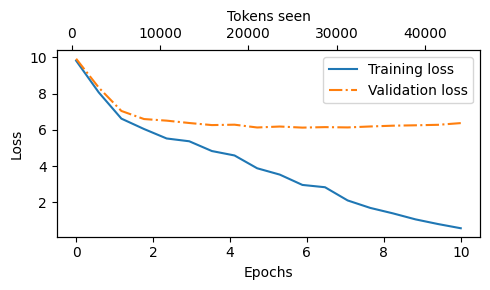

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 观察上面的结果，我们可以看到模型一开始生成的是难以理解的单词串，而到了最后，它能够生成语法上或多或少正确的句子
- 然而，基于训练集和验证集的损失，我们可以看到模型开始过拟合
- 如果我们要检查它在最后写的几段话，我们会发现它们逐字逐句地包含在训练集中——它只是记住了训练数据
- 稍后，我们将介绍可以在一定程度上减轻这种记忆的解码策略
- 请注意，这里的过拟合发生是因为我们有一个非常非常小的训练集，并且我们对它进行了多次迭代
  - 这里的 LLM 训练主要用于教育目的；我们主要想看看模型能否学会生成连贯的文本
  - 我们稍后将加载预训练权重，而不是花费数周或数月在大量昂贵的硬件上训练此模型

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/13.webp" width=350px>

**如果您有兴趣使用更高级的技术（例如学习率预热、余弦退火和梯度裁剪）来增强此训练函数，请参阅 [附录 D](../../appendix-D/01_main-chapter-code)**

**如果您对更大的训练数据集和更长的训练运行感兴趣，请参阅 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)**

&nbsp;
## 5.3 控制随机性的解码策略

- 对于像我们上面训练的 GPT 模型这样相对较小的 LLM，推理相对便宜，因此如果您在上面使用 GPU 进行训练，则无需使用 GPU 进行推理
- 使用我们之前在简单训练函数中使用的 `generate_text_simple` 函数（来自上一章），我们可以一次生成一个单词（或标记）的新文本
- 正如第 5.1.2 节所解释的那样，下一个生成的标记是对应于词汇表中所有标记中最大概率分数的标记

In [29]:
# NEW: use CPU here as inference is cheap with 
# this model and to ensure readers get same results in the
# remaining sections of this book
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




- 即使我们多次执行上面的 `generate_text_simple` 函数，LLM 也总是会生成相同的输出
- 我们现在介绍两个概念，即所谓的解码策略，以修改 `generate_text_simple`：*温度缩放*和*top-k* 采样
- 这些将允许模型控制生成文本的随机性和多样性

&nbsp;
### 5.3.1 温度缩放

- 以前，我们总是使用 `torch.argmax` 采样概率最高的标记作为下一个标记
- 为了增加多样性，我们可以使用 `torch.multinomial(probs, num_samples=1)` 采样下一个标记，从概率分布中采样
- 这里，每个索引被选中的机会对应于它在输入张量中的概率

- 这是生成下一个标记的简要回顾，假设用于说明目的的词汇表非常小：

In [30]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

forward


In [31]:
- 我们不使用 `torch.argmax` 确定最可能的标记，而是使用 `torch.multinomial(probas, num_samples=1)` 通过从 softmax 分布中采样来确定最可能的标记
- 为了说明目的，让我们看看当我们使用原始 softmax 概率采样下一个标记 1,000 次时会发生什么：

forward


- Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution
- For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [32]:
- 我们可以通过一个称为温度缩放的概念来控制分布和选择过程
- “温度缩放”只是一个花哨的词，意思是将 logits 除以大于 0 的数
- 大于 1 的温度将在应用 softmax 后导致更均匀分布的标记概率
- 小于 1 的温度将在应用 softmax 后导致更自信（更尖锐或更峰值）的分布

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- 请注意，生成的 Dropout 输出可能会因您的操作系统而异；您可以在 [PyTorch 问题追踪器](https://github.com/pytorch/pytorch/issues/121595) 上阅读有关此不一致性的更多信息

- Note that the resulting dropout outputs may look different depending on your operating system; you can read more about this inconsistency [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

In [33]:
- 我们可以看到，通过温度 0.1 进行重新缩放会导致更尖锐的分布，接近 `torch.argmax`，从而几乎总是选择最可能的单词：

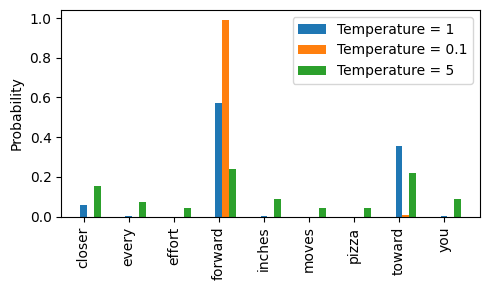

In [34]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- 通过温度 5 重新缩放的概率分布更加均匀：

In [35]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


- 假设 LLM 输入为“every effort moves you”，使用上述方法有时会导致无意义的文本，例如“every effort moves you pizza”，占 3.2%（1000 次中有 32 次）

In [36]:
&nbsp;
### 5.3.2 Top-k 采样

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- 为了能够使用更高的温度来增加输出多样性并减少无意义句子的概率，我们可以将采样的标记限制为前 k 个最可能的标记：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=500px>

- （请注意，此图中的数字在小数点后截断为两位数，以减少视觉混乱。Softmax 行中的值总和应为 1.0。）

- 在代码中，我们可以按如下方式实现：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=500px>

- (Please note that the numbers in this figure are truncated to two
digits after the decimal point to reduce visual clutter. The values in the Softmax row should add up to 1.0.)

- In code, we can implement this as follows:

In [37]:
> 注意：
>
>  上一个代码单元的另一种稍微更有效的实现如下：
>
> ```python
> new_logits = torch.full_like( # create tensor containing -inf values
>    next_token_logits, -torch.inf
>)   
> new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
> ```
> <br>
> 有关更多详细信息，请参阅 https://github.com/rasbt/LLMs-from-scratch/discussions/326


Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [38]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


&nbsp;
### 5.3.3 修改文本生成函数

In [39]:
- 前两个小节介绍了温度采样和 top-k 采样
- 让我们使用这两个概念来修改第 4 章中的 `generate_text_simple` 函数，创建一个新的 `generate` 函数：

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


&nbsp;
## 5.4 在 PyTorch 中加载和保存模型权重

- 训练 LLM 的计算成本很高，因此能够保存和加载 LLM 权重至关重要

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/16.webp" width=400px>

In [40]:
- PyTorch 中推荐的方法是保存模型权重，即所谓的 `state_dict`，通过对 `.state_dict()` 方法应用 `torch.save` 函数：

In [41]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand," she down." For Mrs. Gisburn! The women had


- 然后，我们可以按如下方式将模型权重加载到新的 `GPTModel` 模型实例中：

- Training LLMs is computationally expensive, so it's crucial to be able to save and load LLM weights

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/16.webp" width=400px>

- 使用 Adam 或 AdamW 等自适应优化器而不是常规 SGD 来训练 LLM 是很常见的
- 这些自适应优化器为每个模型权重存储额外的参数，因此如果我们计划稍后继续预训练，将它们也保存起来是有意义的：

In [42]:
torch.save(model.state_dict(), "model.pth")

- Then we can load the model weights into a new `GPTModel` model instance as follows:

In [43]:
&nbsp;
## 5.5 从 OpenAI 加载预训练权重

- 以前，我们只使用一本非常小的短篇故事书训练了一个小型 GPT-2 模型用于教育目的
- 感兴趣的读者还可以在 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg) 中找到在完整的古腾堡计划图书语料库上进行的更长的预训练运行
- 幸运的是，我们不必花费数万到数十万美元在大型预训练语料库上预训练模型，而是可以加载 OpenAI 提供的预训练权重

In [44]:
---

---


⚠️ **注意：由于 TensorFlow 兼容性问题，特别是某些 Windows 系统，部分用户可能会在本节遇到问题。这里需要 TensorFlow 仅是为了加载原始 OpenAI GPT-2 权重文件，然后我们将其转换为 PyTorch。
如果您遇到与 TensorFlow 相关的问题，可以使用下面的替代代码代替本节中的剩余代码。
此替代方案基于预转换的 PyTorch 权重，使用上一节中描述的相同转换过程创建。有关详细信息，请参阅笔记本：
[../02_alternative_weight_loading/weight-loading-pytorch.ipynb](../02_alternative_weight_loading/weight-loading-pytorch.ipynb)。**

```python
file_name = "gpt2-small-124M.pth"


In [45]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

&nbsp;
## 5.5 Loading pretrained weights from OpenAI

- 首先，一些用于从 OpenAI 下载文件并将权重加载到 Python 中的样板代码
- 由于 OpenAI 使用了 [TensorFlow](https://www.tensorflow.org/)，我们将必须安装并使用 TensorFlow 来加载权重；[tqdm](https://github.com/tqdm/tqdm) 是一个进度条库
- 取消注释并运行下一个单元格以安装所需的库

---

---


⚠️ **Note: Some users may encounter issues in this section due to TensorFlow compatibility problems, particularly on certain Windows systems. TensorFlow is required here only to load the original OpenAI GPT-2 weight files, which we then convert to PyTorch.
If you're running into TensorFlow-related issues, you can use the alternative code below instead of the remaining code in this section.
This alternative is based on pre-converted PyTorch weights, created using the same conversion process described in the previous section. For details, refer to the notebook:
[../02_alternative_weight_loading/weight-loading-pytorch.ipynb](../02_alternative_weight_loading/weight-loading-pytorch.ipynb) notebook.**

```python
file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")

gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
gpt.eval()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")
gpt.to(device);


torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))
```

---

---

- First, some boilerplate code to download the files from OpenAI and load the weights into Python
- Since OpenAI used [TensorFlow](https://www.tensorflow.org/), we will have to install and use TensorFlow for loading the weights; [tqdm](https://github.com/tqdm/tqdm) is a progress bar library
- Uncomment and run the next cell to install the required libraries

In [46]:
# pip install tensorflow tqdm

In [47]:
---

**注意**

- 在极少数情况下，上面的代码单元可能会导致 `zsh: illegal hardware instruction python` 错误，这可能是由于您机器上的 TensorFlow 安装问题
- 一位读者发现通过 `conda` 安装 TensorFlow 解决了这个特定情况下的问题，正如 [这里](https://github.com/rasbt/LLMs-from-scratch/discussions/273#discussioncomment-12367888) 所提到的
- 您可以在此补充 [Python 设置教程](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup/01_optional-python-setup-preferences#option-2-using-conda) 中找到更多说明

---

- 然后我们可以按如下方式下载 124M 参数模型的模型权重：

TensorFlow version: 2.20.0
tqdm version: 4.67.1


In [48]:
# Relative import from the gpt_download.py contained in this folder

from gpt_download import download_and_load_gpt2
# Alternatively:
# from llms_from_scratch.ch05 import download_and_load_gpt2

---

**Note**

- In very rare cases, the code cell above may result in a `zsh: illegal hardware instruction python` error, which could be due to a TensorFlow installation issue on your machine
- A reader found that installing TensorFlow via `conda` solved the issue in this specific case, as mentioned [here](https://github.com/rasbt/LLMs-from-scratch/discussions/273#discussioncomment-12367888)
- You can find more instructions in this supplementary [Python setup tutorial](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup/01_optional-python-setup-preferences#option-2-using-conda)

---

- We can then download the model weights for the 124 million parameter model as follows:

In [49]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [50]:
- 正如我们所看到的，124M GPT-2 模型具有：
    - 50257 个词汇表大小
    - 1024 个上下文长度
    - 768 个嵌入大小
    - 12 个注意力头
    - 12 个层（Transformer 块）
- `params` 字典包含每个层的权重张量（numpy 数组）

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [51]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [52]:
- 为了将这些权重加载到我们自己的 GPT 实现中，我们首先创建一个新的 `GPTModel` 实例
- 请注意，我们在这里使用 `NEW_CONFIG`，因为原始 GPT-2 模型使用了偏置向量，我们之前禁用了它，并且它使用了 1024 的上下文长度（我们之前为了提高计算效率使用了 256）

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


- Alternatively, "355M", "774M", and "1558M" are also supported `model_size` arguments
- The difference between these differently sized models is summarized in the figure below:

- 现在的任务是将 OpenAI `params` 字典中的权重分配给我们 `model` 实例中的相应张量
- 我们将为此定义一个 `load_weights_into_gpt` 函数；由于这需要大量的代码，因此将其分解为子步骤进行解释
- 但是，在我们实现 `load_weights_into_gpt` 函数之前，让我们看看 OpenAI 和我们的实现中权重名称是如何对应的
- 正如我们在下面看到的，权重张量名称略有不同：

- Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our `GPTModel` instance
- First, we initialize a new GPTModel instance
- Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting `qkv_bias` to `True` in our implementation, too
- We are also using the `1024` token context length that was used by the original GPT-2 model(s)

In [53]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- 或者，"355M"、"774M" 和 "1558M" 也是受支持的 `model_size` 参数
- 下图总结了这些不同大小的模型之间的差异：

In [54]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [55]:
- 上面，我们将 124M GPT-2 模型权重加载到了 Python 中，但是我们仍然需要将它们传输到我们的 `GPTModel` 实例中
- 首先，我们初始化一个新的 GPTModel 实例
- 请注意，原始 GPT 模型使用偏置向量初始化多头注意力模块中的查询、键和值矩阵的线性层，这是不需要或不推荐的；但是，为了能够正确加载权重，我们也必须在我们的实现中通过将 `qkv_bias` 设置为 `True` 来启用这些
- 我们也使用了原始 GPT-2 模型所使用的 `1024` 标记上下文长度

- If the model is loaded correctly, we can use it to generate new text using our previous `generate` function:

In [56]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




- 下一个任务是将 OpenAI 权重分配给我们 `GPTModel` 实例中的相应权重张量

- For an alternative way to load the weights from the Hugging Face Hub, see [../02_alternative_weight_loading](../02_alternative_weight_loading)
- If you are interested in seeing how the GPT architecture compares to the Llama architecture (a popular LLM developed by Meta AI), see the bonus content at [../07_gpt_to_llama](../07_gpt_to_llama)

&nbsp;
## Summary and takeaways

- 如果模型加载正确，我们可以使用它来生成新文本，使用我们之前的 `generate` 函数：